/tmp/ipykernel_4543/3864382471.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_df, x="Importance", y="Feature", palette="viridis")


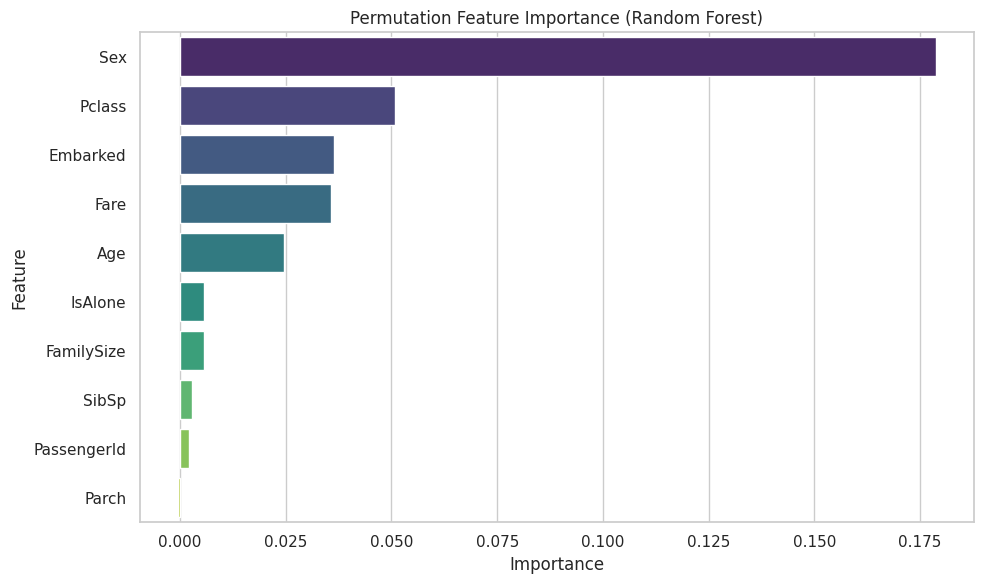

In [13]:
# day22_permutation_importance.ipynb

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: for prettier plots
sns.set(style="whitegrid")

# Load cleaned Titanic dataset
df = pd.read_csv("../day02-python-problems/cleaned_titanic.csv")

# Separate features and target
X = df.drop(columns=["Survived", "Name"])
y = df["Survived"]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Permutation Importance
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

# Convert to DataFrame
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df, x="Importance", y="Feature", palette="viridis")
plt.title("Permutation Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()
